In [4]:
from sklearn.datasets import load_wine
import pandas as pd

# Load the wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Optional: include original class labels
df['target'] = wine.target

# Preview the data
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Preparing Data**

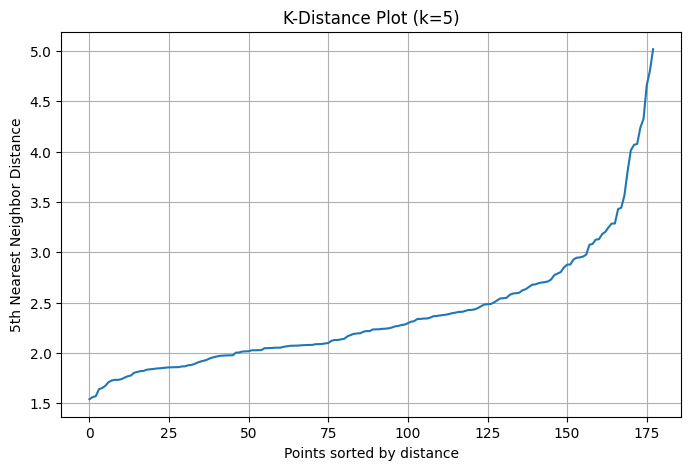

In [7]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Fit Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort and plot distances
distances = np.sort(distances[:, 4])
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Plot (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()



In [20]:
from sklearn.cluster import DBSCAN

# Choose eps based on elbow in K-Distance plot
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df['cluster'] = labels

# View cluster distribution
df['cluster'].value_counts()


,count
cluster,
-1,178


Shows 178 points in cluster -1 all are noise.

In [21]:
from sklearn.cluster import DBSCAN

# Choose eps based on elbow in K-Distance plot
dbscan = DBSCAN(eps=2, min_samples=4)
labels = dbscan.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df['cluster'] = labels

# View cluster distribution
df['cluster'].value_counts()

,count
cluster,
0,77
-1,66
4,14
1,6
2,6
3,5
5,4


Still shows 66 point in -1 cluster.

In [ ]:
from sklearn.cluster import DBSCAN

# Choose eps based on elbow in K-Distance plot
dbscan = DBSCAN(eps=4, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df['cluster'] = labels

# View cluster distribution
df['cluster'].value_counts()

Oringally, 178 points do not belong to any cluster based on with the settings set to eps=1.5, min_samples=5. But I continued to play with eps and min_samples and found that with settings at eps=4, min_samples=3, we have no boise. This has allowed DBSCAN to successfully form clusters instead of labeling everything as noise.


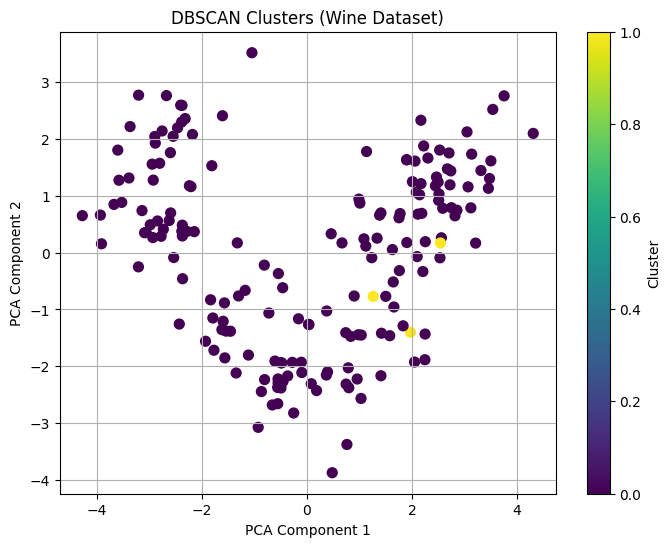

Silhouette Score: 0.2224506072765093


In [17]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], c=df['cluster'], cmap='viridis', s=50)
plt.title('DBSCAN Clusters (Wine Dataset)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

from sklearn.metrics import silhouette_score

# Only compute if valid clusters exist
if len(set(labels)) > 1 and -1 not in set(labels):
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score not applicable due to noise or single cluster.")


DBSCAN clustering results on the Wine dataset:

- **Clustering Outcome**: DBSCAN identified a small number of clusters, with most data points grouped into a single dominant cluster (dark purple) and a few scattered points forming minor clusters (yellow). Several points were labeled as noise.

- **Silhouette Score**: The score is **0.22**, indicates weak cluster separation. This is expected with DBSCAN on nonconvex shapes and noisy data, as the silhouette metric favors well-separated, convex clusters.

- **Visual Insight**: The PCA scatter plot shows that DBSCAN captured some local density variations but struggled to form multiple distinct groups. The presence of noise points suggests DBSCAN is sensitive to the chosen `eps` and `min_samples`.

- **Interpretation**: The dominant cluster likely represents wines with typical chemical profiles, while smaller clusters and noise may correspond to outliers or rare compositions.


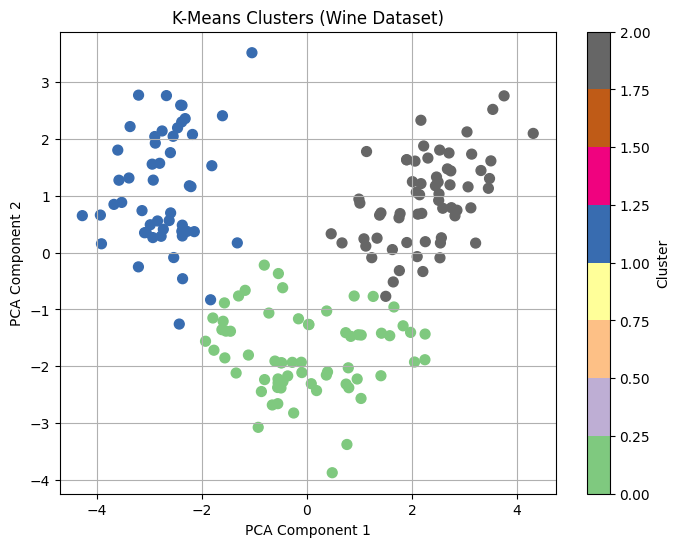

In [18]:
from sklearn.cluster import KMeans

# Apply K-Means with 3 clusters (known from original labels)
kmeans = KMeans(n_clusters=3, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

# Add K-Means labels to DataFrame
df['kmeans_cluster'] = k_labels

# Visualize K-Means clusters
components_k = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(components_k[:, 0], components_k[:, 1], c=df['kmeans_cluster'], cmap='Accent', s=50)
plt.title('K-Means Clusters (Wine Dataset)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

**K- mean Clustering Outcome**:

K-Means successfully identified **three distinct clusters**, each represented by a different color. The clusters are well-separated in the PCA-reduced space, suggesting clear groupings based on chemical composition.

Compared to DBSCAN, K-Means forms more balanced and compact clusters without labeling any points as noise. This reflects its tendency to partition all data, even if some points don’t fit well.


In [19]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Load and scale the Wine dataset
wine = load_wine()
X = wine.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=4, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Filter out noise points (-1) for silhouette score
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: Not applicable (only one cluster or all noise)")

K-Means Silhouette Score: 0.2849
DBSCAN Silhouette Score: 0.2225


- **K-Means** achieved a **higher silhouette score (0.2849)**, indicating more clearly separated and compact clusters. This aligns with its assumption of spherical, evenly sized groups.

- **DBSCAN** produced a **lower silhouette score (0.2225)**, reflecting its flexibility in detecting nonconvex shapes and noise—but also its sensitivity to parameter tuning and the presence of outliers.



**Cluster Interpretation and Comparison**

**DBSCAN Results**  
DBSCAN found one main cluster and a few smaller ones, with several points labeled as noise.  
- The main cluster includes wines with typical chemical profiles.  
- Smaller clusters may represent unique wine types.  
- Noise points are wines that don’t fit into any group — possibly rare blends or measurement outliers. These could be interesting for further study.

**K-Means Results**  
K-Means formed three well-separated clusters, which likely match the original wine classes.  
- Each group has a distinct chemical signature.  
- No noise points — every wine is forced into a cluster, even if it doesn’t fit well.

**Comparison**  
- **DBSCAN** captures unusual patterns and outliers, making it better for exploring structure and anomalies.  
- **K-Means** gives cleaner, more balanced clusters but may oversimplify the data.  
- For this dataset, **DBSCAN** offers deeper insight into variation, while **K-Means** is better for clear group separation.

